In [63]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.get_dataset_names()
df=sns.load_dataset('titanic')
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [64]:
df.shape

(891, 15)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [66]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [67]:
# 2. Clasifica las variables `survived`, `pclass`, `sex`, `age`, `sibsp`, `fare`, `embarked`, `deck`
# y `alone` como cuantitativas o cualitativas; cuando corresponda, indica si son
# discretas/continuas o nominales/ordinales. Explica al menos dos “disfraces numéricos”.
# Pista de trabajo: No clasifiques solo por el dtype de pandas; piensa en el significado.

clasificacion_variables=pd.DataFrame({
    'variable':['survived','pclass','sex', 'age', 'sibsp','fare', 'embarked', 'deck', 'alone'],
    'clasificacion':[
        'categoria - nominal',
        'categoria - ordinal',
        'categoria - nominal',
        'numerica - discreta',
        'numerica - discreta',
        'numerica - continua',
        'categoria - nominal',
        'categoria - nominal',
        'categoria - nominal',
    ]
})
clasificacion_variables

,variable,clasificacion
0,survived,categoria - nominal
1,pclass,categoria - ordinal
2,sex,categoria - nominal
3,age,numerica - discreta
4,sibsp,numerica - discreta
5,fare,numerica - continua
6,embarked,categoria - nominal
7,deck,categoria - nominal
8,alone,categoria - nominal


In [68]:
# 3. Analiza los valores faltantes. Calcula cantidad y porcentaje de nulos por columna, ordénalos
# de mayor a menor y propone una estrategia razonada para `deck`, `age` y
# `embarked`/`embark_town`.

valores_nulos= pd.DataFrame({
    "numero_nulos": df.isna().sum(),
    "porcentaje": df.isna().mean()*100
}).sort_values("porcentaje",ascending=False)

valores_nulos

,numero_nulos,porcentaje
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [69]:
# 4. Busca filas exactamente duplicadas. ¿Cuántas hay? Explica por qué “fila duplicada” no
# equivale necesariamente a “pasajero duplicado” en este archivo y por qué no deberías
# eliminarlas automáticamente.
# Pista de trabajo: Comprueba si existe un identificador único de pasajero.
numero_duplicados= df.duplicated().sum()
duplicados=df[df.duplicated(keep=False)].sort_values(list(df.columns))

print(numero_duplicados)

107


In [70]:
duplicados

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
64,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
144,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
757,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
658,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
643,1,3,male,NaN,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
692,1,3,male,NaN,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
65,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False


In [71]:
# 5. Calcula estadísticos descriptivos de `age` y `fare`: media, mediana, desviación estándar,
# Q1, Q3 e IQR. Compara media y mediana y comenta qué sugieren sobre la forma de cada
# distribución.
# Pista de trabajo: La distancia entre media y mediana puede dar una primera pista de asimetría.
resumen= df[["age","fare"]].agg(["mean","median","std"])
resumen

q= df[["age","fare"]].quantile([0.25,0.75])
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]
q

,q1,q3,iqr
0.25,20.125,7.9104,-12.2146
0.75,38.000,31.0000,-7.0000


In [72]:
resumen

,age,fare
mean,29.699118,32.204208
median,28.000000,14.454200
std,14.526497,49.693429


<Axes: xlabel='age', ylabel='Count'>

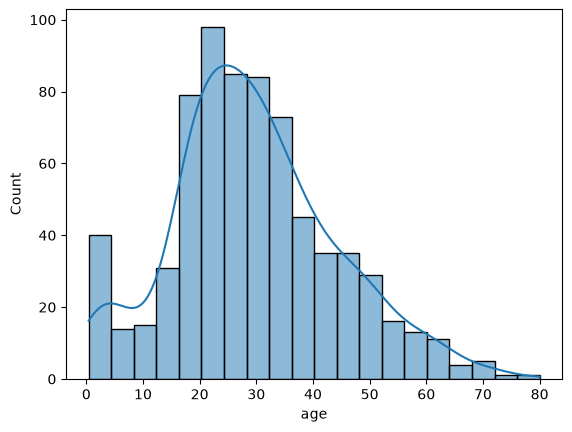

In [73]:
# 6. Realiza un análisis univariado de `age` mediante histograma y curva KDE. Describe centro,
# dispersión, forma y cualquier precaución por los datos faltantes.
# Pista de trabajo: No confundas una forma visual con una prueba formal de normalidad.
sns.histplot(data=df,x="age", bins=20, kde=True)

<Axes: xlabel='fare', ylabel='Count'>

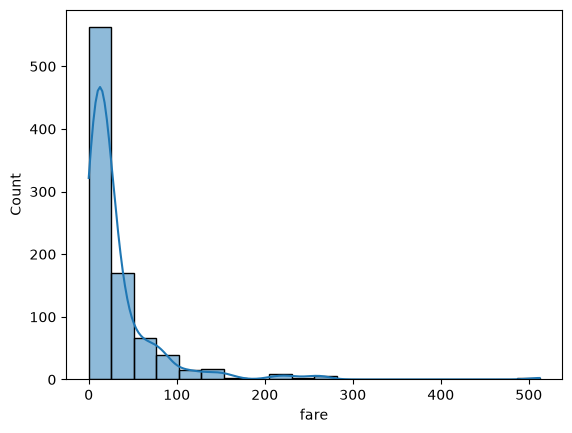

In [74]:
sns.histplot(data=df,x="fare", bins=20, kde=True)

age     -6.6875
fare   -26.7240
dtype: float64
age     64.8125
fare    65.6344
dtype: float64


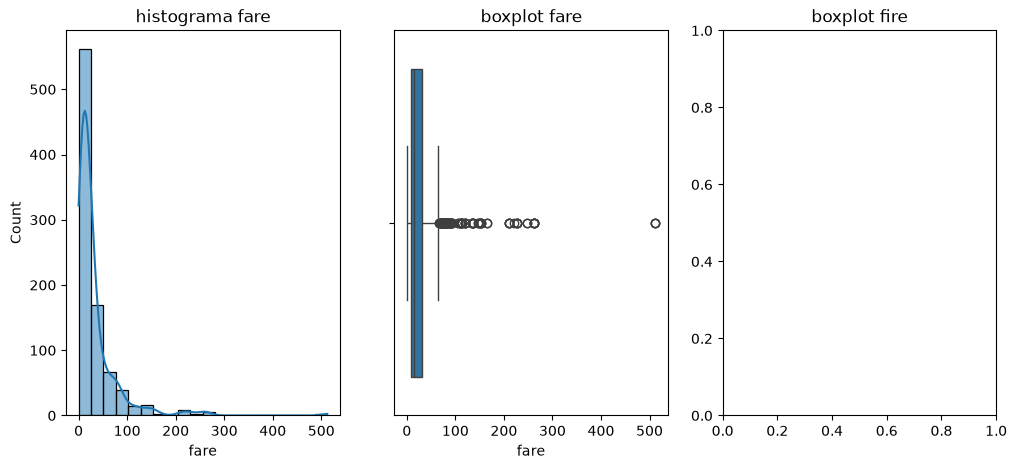

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [79]:
fig, axes=plt.subplots(1,3, figsize=(12,5))
sns.histplot(data=df,x="fare", bins=20, kde=True, ax=axes[0])
axes[0].set_title("histograma fare")
sns.boxplot(data=df,x="fare", ax=axes[1])
axes[1].set_title("boxplot fare")

q= df[["age","fare"]].quantile([0.25,0.75]).T
q.columns=["q1","q3"]
q["iqr"]=q["q3"]-q["q1"]

lower= q["q1"]-1.5*q["iqr"]
print(lower)

upper=q["q3"]+1.5*q["iqr"]
print(upper)

df_sin= df[(df["fare"] < lower["fare"]) & (df["fare"] > upper["fare"])]

sns.boxplot(data=df_sin, x="fare",ax=axes[2])
axes[2].set_title("boxplot fire")

plt.show()
df_sin
    

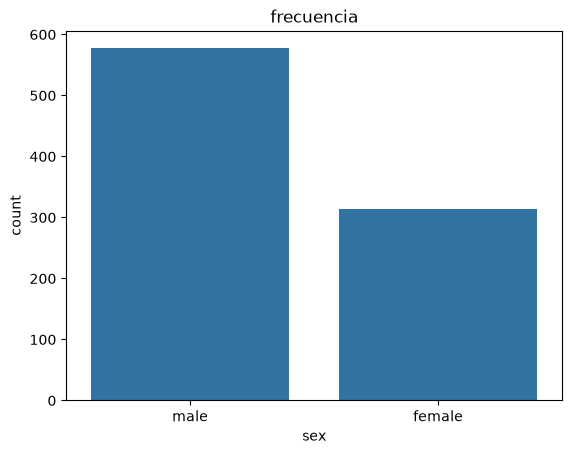

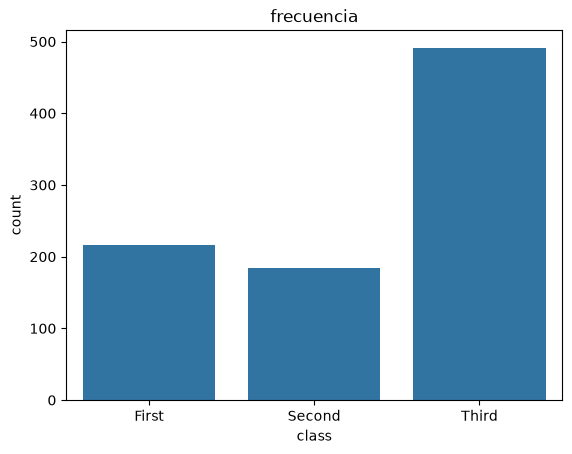

In [81]:
# 8. Explora las variables categóricas `sex` y `class` con tablas de frecuencia y gráficos de
# barras. ¿Qué grupos dominan el dataset y qué implicación puede tener para las
# comparaciones?
# Pista de trabajo: `value_counts()` y proporciones.

for col in ["sex","class"]:
    sns.countplot(data=df,x=col)
    plt.title(f"frecuencia")
    plt.show()

# df[["sex","class"]].value_counts()

survived
0    549
1    342
Name: count, dtype: int64
38.38383838383838


Text(0.5, 1.0, 'supervivencia')

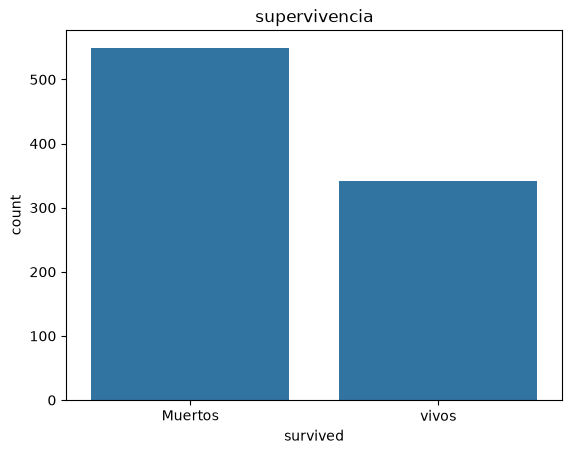

In [87]:
# 9. Calcula la tasa global de supervivencia y represéntala gráficamente. Interpreta la diferencia
# entre contar supervivientes y calcular una tasa.

counts = df["survived"].value_counts()
print(counts)

tasa= df["survived"].mean()*100
print(tasa)

sns.countplot(data=df,x="survived")
plt.xticks([0,1],["Muertos","vivos"])
plt.title("supervivencia")

        count       mean
sex                     
female    314  74.203822
male      577  18.890815


<Axes: xlabel='sex', ylabel='survived'>

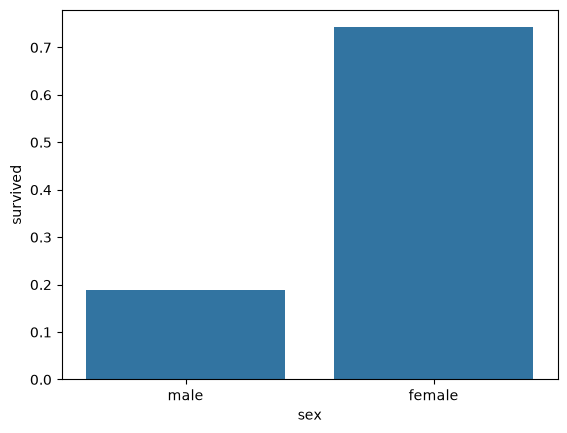

In [93]:
# 10. Compara la tasa de supervivencia entre mujeres y hombres. Incluye una tabla y un gráfico.
# Describe la asociación observada sin usar lenguaje causal.
sex_ratr= df.groupby("sex")["survived"].agg(["count","mean"])
sex_ratr["mean"]*=100

print(sex_ratr)

sns.barplot(data=df,x="sex",y="survived",errorbar=None)

<Axes: xlabel='class', ylabel='survived'>

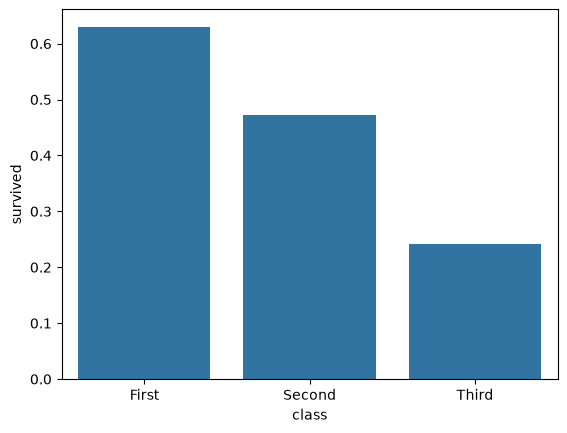

In [95]:
# 11. Compara la tasa de supervivencia entre primera, segunda y tercera clase. ¿Existe un
# gradiente visible entre las clases?
class_rate= df.groupby("class")["survived"].agg(["count","mean"])
class_rate["mean"]*=100

class_rate
sns.barplot(data=df,x="class", y="survived",errorbar=None)

          count       mean  median        std
survived                                     
0           424  30.626179    28.0  14.172110
1           290  28.343690    28.0  14.950952


<Axes: xlabel='survived', ylabel='age'>

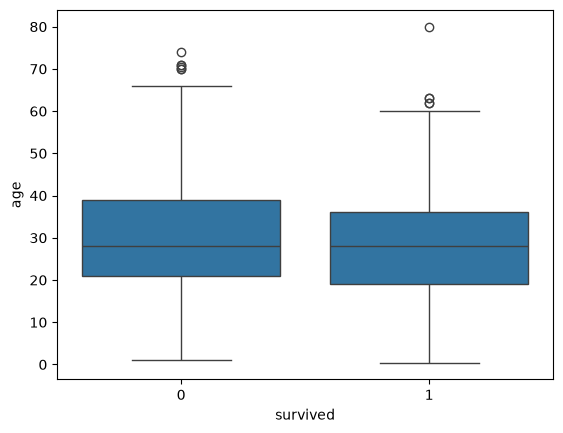

In [100]:
age_status=df.groupby("survived")["age"].agg(["count","mean","median","std"])
print(age_status)

sns.boxplot(data=df,x="survived",y="age")

In [ ]:
# 13. Construye una matriz de correlación para las variables numéricas y un heatmap. Identifica
# las relaciones lineales más relevantes con `survived` y explica por qué correlación no implica
# causalidad.
columnas_numericas=df.select_dtypes(include="number")

sns.heatmap()
